<h2>FicZon Inc.   -  Sales Lead Quality Prediction</h2>



<h3>Business Problem: </h3>

FicZon Inc. generates leads mainly through its website. Right now, sales staff manually categorize leads as good or bad, which is slow, inconsistent, and only useful for after-the-fact analysis — not for helping the sales team prioritize right now.

<h3>Project Goals:</h3>

Data Exploration & Insights — understand what drives sales effectiveness.
ML Model — predict Lead Category (High Potential / Low Potential) automatically, so the sales team can focus effort on the leads most likely to convert.

In [1]:
# Core data handling
import pandas as pd
import numpy as np
import re

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Preprocessing & modeling (scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

# Show all columns when printing a DataFrame
pd.set_option('display.max_columns', None)


In [2]:
!pip install pymysql sqlalchemy -q

In [3]:
#Passwprd : DM!$Team&27@9!20!
import getpass
import pymysql

password = getpass.getpass("Enter MySQL password: ")

try:
    connection = pymysql.connect(
        host="18.136.157.135",
        port=3306,
        user="dm_team2",
        password=password,
        database="project_sales",
        connect_timeout=10
    )

    print("✅ Database connection successful!")

except Exception as e:
    print("❌ Connection failed:")
    print(e)

Enter MySQL password:  ········


✅ Database connection successful!


print(connection.open)

In [4]:
import pandas as pd

df = pd.read_sql("SELECT * FROM data", connection)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

/var/folders/2v/22wl5htd30n9h88xcppbwkwr0000gn/T/ipykernel_792/2093841005.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM data", connection)


Dataset loaded successfully!
Shape: (7422, 9)


,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,,Mode-5,Open
1,14-11-2018 09:22,,Website,XXXXXXX,#VALUE!,Sales-Agent-10,,Mode-5,Open
2,14-11-2018 09:21,,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,,Mode-5,Open
3,14-11-2018 08:46,,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
4,14-11-2018 07:34,,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open


<h2>Data UnderStanding</h2>

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Created        7422 non-null   object
 1   Product_ID     7422 non-null   object
 2   Source         7422 non-null   object
 3   Mobile         7422 non-null   object
 4   EMAIL          7422 non-null   object
 5   Sales_Agent    7422 non-null   object
 6   Location       7422 non-null   object
 7   Delivery_Mode  7422 non-null   object
 8   Status         7422 non-null   object
dtypes: object(9)
memory usage: 522.0+ KB


In [6]:
df.head(10)

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,,Mode-5,Open
1,14-11-2018 09:22,,Website,XXXXXXX,#VALUE!,Sales-Agent-10,,Mode-5,Open
2,14-11-2018 09:21,,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,,Mode-5,Open
3,14-11-2018 08:46,,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
4,14-11-2018 07:34,,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
5,14-11-2018 07:33,,Website,XXXXXXX,rXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
6,14-11-2018 05:58,,Website,XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
7,14-11-2018 05:49,,Website,XXXXXXX,rXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
8,14-11-2018 05:40,,Website,078XXXXXXX,DXXXXXXXheblue.com,Sales-Agent-10,,Mode-5,Open
9,14-11-2018 05:06,,Website,XXXXXXX,jXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open


In [7]:
for col in df.columns:
    print("\n" + "="*50)
    print(f"COLUMN: {col}")
    print("="*50)
    print("Data type:", df[col].dtype)
    print("Unique values:", df[col].nunique())
    print("\nTop values:")
    print(df[col].value_counts(dropna=False).head(15))


COLUMN: Created
Data type: object
Unique values: 6752

Top values:
Created
26-09-2018 11:30    4
27-09-2018 11:00    4
10-05-2018 12:30    4
15-10-2018 10:36    4
14-09-2018 12:00    4
02-07-2018 10:12    3
19-06-2018 12:10    3
30-04-2018 11:13    3
03-09-2018 11:47    3
24-09-2018 10:48    3
01-08-2018 10:23    3
03-09-2018 11:00    3
09-05-2018 12:45    3
05-06-2018 09:37    3
31-07-2018 18:31    3
Name: count, dtype: int64

COLUMN: Product_ID
Data type: object
Unique values: 30

Top values:
Product_ID
18    1711
15    1518
19    1189
9      992
27     739
5      487
10     168
1      105
20     102
25      90
21      66
        58
2       38
12      36
26      31
Name: count, dtype: int64

COLUMN: Source
Data type: object
Unique values: 26

Top values:
Source
Call                        2547
Live Chat-Direct            1834
Website                     1594
Live Chat-Google Organic     274
Live Chat -PPC               249
Live Chat-Blog               237
Customer Referral          

<h2> Exploratory Data Analysis (EDA)</h2>

We look at each column one by one to understand:
- how much data is missing
- what the categories look like
- what "Status" (the raw manual tag) tells us about lead outcomes

In [8]:
# Count of missing values per column
df.isnull().sum().sort_values(ascending=False)

Created          0
Product_ID       0
Source           0
Mobile           0
EMAIL            0
Sales_Agent      0
Location         0
Delivery_Mode    0
Status           0
dtype: int64

In [9]:
# Percentage of missing values per column (easier to judge severity)
(df.isnull().mean() * 100).round(2).sort_values(ascending=False)


Created          0.0
Product_ID       0.0
Source           0.0
Mobile           0.0
EMAIL            0.0
Sales_Agent      0.0
Location         0.0
Delivery_Mode    0.0
Status           0.0
dtype: float64

In [10]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 2


In [11]:
# The raw target information lives in 'Status' (manually tagged by sales staff)
df['Status'].value_counts()


Status
Junk Lead               1536
Not Responding          1129
CONVERTED                834
Just Enquiry             760
Potential                708
Long Term                646
In Progress Positive     643
In Progress Negative     626
LOST                     440
Open                      82
converted                 18
Name: count, dtype: int64

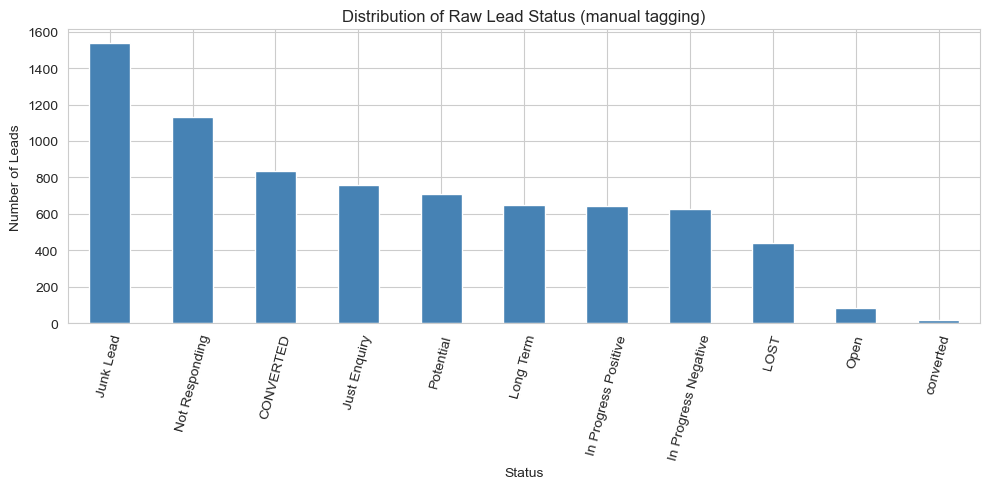

In [12]:
# Visualize the raw Status distribution
plt.figure(figsize=(10, 5))
df['Status'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribution of Raw Lead Status (manual tagging)')
plt.xlabel('Status')
plt.ylabel('Number of Leads')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


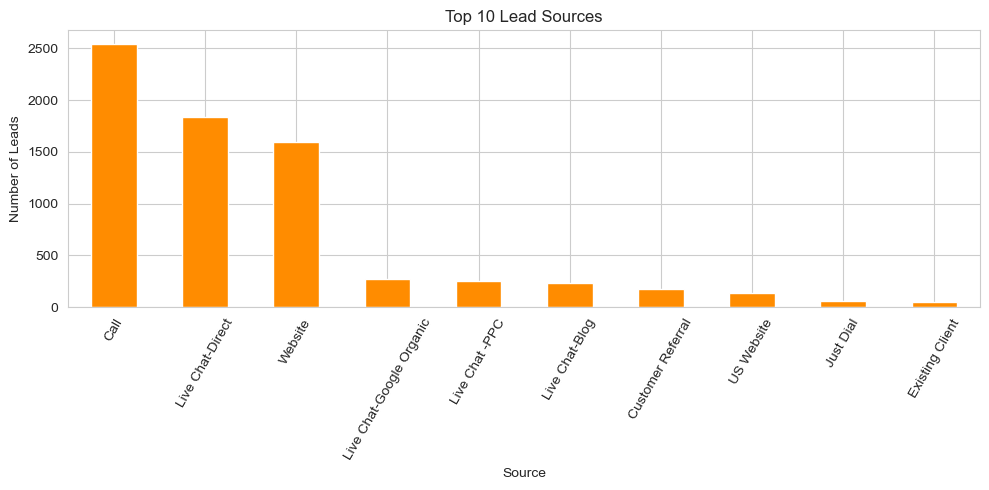

In [13]:
# How are leads coming in? (lead source distribution, top 10)
plt.figure(figsize=(10, 5))
df['Source'].value_counts().head(10).plot(kind='bar', color='darkorange')
plt.title('Top 10 Lead Sources')
plt.xlabel('Source')
plt.ylabel('Number of Leads')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


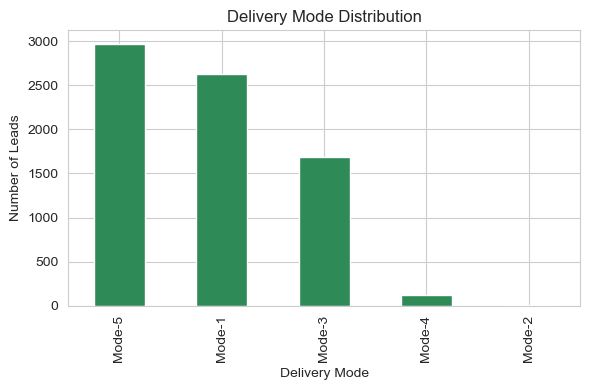

In [14]:
# Delivery mode distribution
plt.figure(figsize=(6, 4))
df['Delivery_Mode'].value_counts().plot(kind='bar', color='seagreen')
plt.title('Delivery Mode Distribution')
plt.xlabel('Delivery Mode')
plt.ylabel('Number of Leads')
plt.tight_layout()
plt.show()


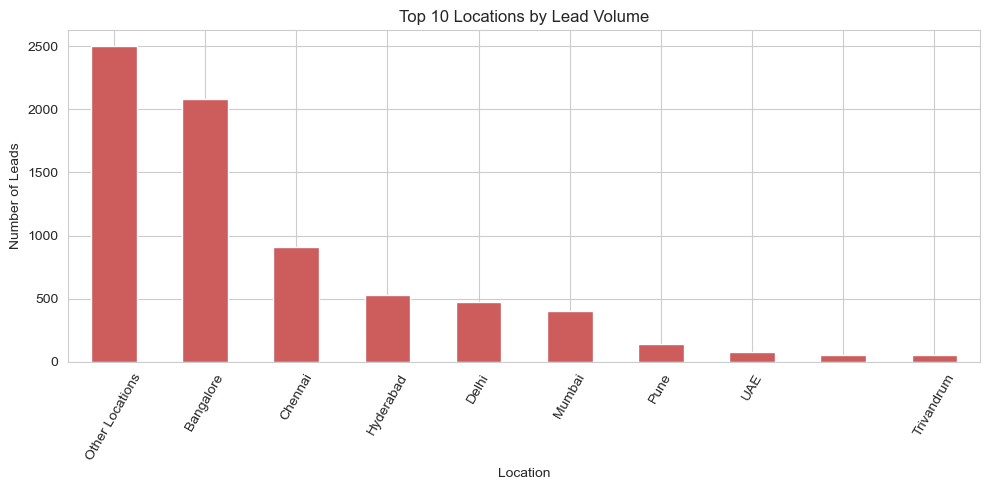

In [15]:
# Top locations generating leads
plt.figure(figsize=(10, 5))
df['Location'].value_counts().head(10).plot(kind='bar', color='indianred')
plt.title('Top 10 Locations by Lead Volume')
plt.xlabel('Location')
plt.ylabel('Number of Leads')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


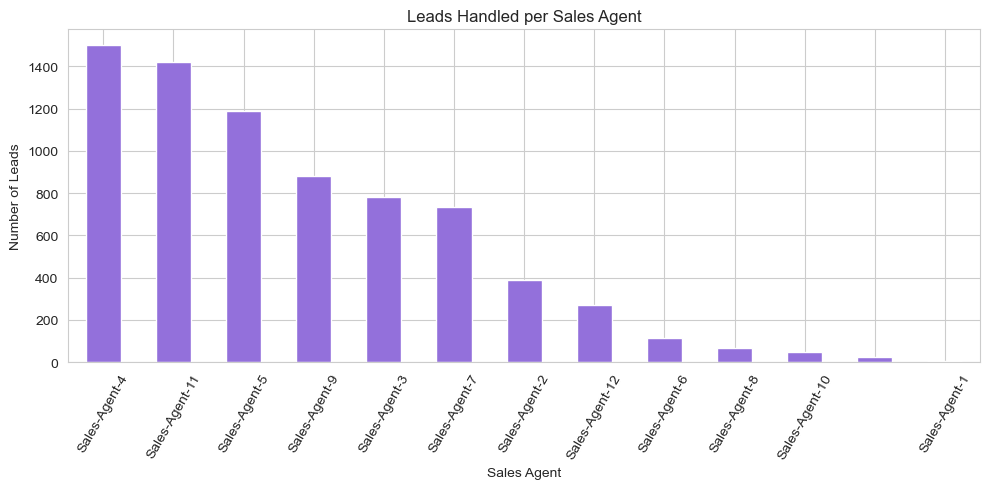

In [16]:
# How many leads does each sales agent handle?
plt.figure(figsize=(10, 5))
df['Sales_Agent'].value_counts().plot(kind='bar', color='mediumpurple')
plt.title('Leads Handled per Sales Agent')
plt.xlabel('Sales Agent')
plt.ylabel('Number of Leads')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


<h2> Feature Engineering — Creating the Target Variable</h2>

In [17]:
# Fix a data entry inconsistency: 'converted' (lowercase) is the same as 'CONVERTED'
df['Status'] = df['Status'].str.strip().replace({'converted': 'CONVERTED'})

# Define which raw statuses count as "Low Potential"
low_potential_status = ['Junk Lead', 'Not Responding', 'In Progress Negative', 'LOST']

# Everything NOT in that list is treated as "High Potential"
df['Lead_Category'] = np.where(df['Status'].isin(low_potential_status),
                                'Low Potential', 'High Potential')

# Check the resulting class balance
df['Lead_Category'].value_counts()


Lead_Category
Low Potential     3731
High Potential    3691
Name: count, dtype: int64

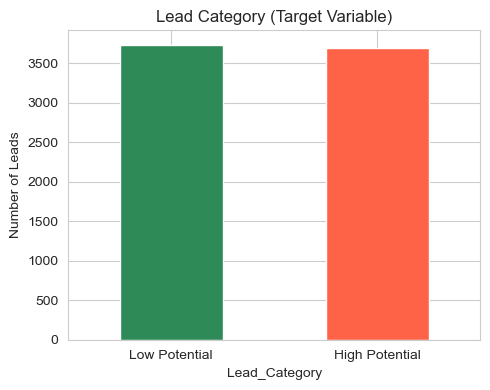

In [18]:
# Visualize the new target -- it should be roughly balanced, which is good for modeling
plt.figure(figsize=(5, 4))
df['Lead_Category'].value_counts().plot(kind='bar', color=['seagreen', 'tomato'])
plt.title('Lead Category (Target Variable)')
plt.ylabel('Number of Leads')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


<h2>Data Cleaning & More Feature Engineering</h2>

In [19]:
# --- Extract date/time features from 'Created' ---
df['Created_dt'] = pd.to_datetime(df['Created'], format='%d-%m-%Y %H:%M', errors='coerce')

df['Created_Hour'] = df['Created_dt'].dt.hour           # hour of day (0-23) the lead came in
df['Created_DayOfWeek'] = df['Created_dt'].dt.dayofweek # 0=Monday ... 6=Sunday
df['Created_Month'] = df['Created_dt'].dt.month         # month of the year

df[['Created', 'Created_Hour', 'Created_DayOfWeek', 'Created_Month']].head()


,Created,Created_Hour,Created_DayOfWeek,Created_Month
0,14-11-2018 10:05,10,2,11
1,14-11-2018 09:22,9,2,11
2,14-11-2018 09:21,9,2,11
3,14-11-2018 08:46,8,2,11
4,14-11-2018 07:34,7,2,11


In [20]:
# --- Has_Mobile flag: 1 if a mobile number was captured, 0 if missing ---
df['Has_Mobile'] = df['Mobile'].notna().astype(int)
df['Has_Mobile'].value_counts()


Has_Mobile
1    7422
Name: count, dtype: int64

In [21]:
# --- Extract email domain as a feature ---

def get_email_domain(value):
    """Return the domain part of an email, or 'unknown' if missing/invalid."""
    
    if pd.isna(value) or value == '#VALUE!':
        return 'unknown'
    
    match = re.search(r'@(.+)$', str(value).lower())
    
    return match.group(1) if match else 'unknown'


df['Email_Domain'] = df['EMAIL'].apply(get_email_domain)


# Keep only the top 4 most common domains,
# bucket the rest as 'other'

top_domains = (
    df['Email_Domain']
    .value_counts()
    .nlargest(4)
    .index
    .tolist()
)

df['Email_Domain_grp'] = df['Email_Domain'].apply(
    lambda d: d if d in top_domains else 'other'
)

print("Top email domains:")
print(df['Email_Domain_grp'].value_counts())

Top email domains:
Email_Domain_grp
gmail.com    4236
unknown      2580
yahoo.com     352
other         223
live.com       31
Name: count, dtype: int64


In [22]:
 # Clean Product_ID safely
df['Product_ID'] = df['Product_ID'].replace(r'^\s*$', pd.NA, regex=True)
df['Product_ID'] = df['Product_ID'].fillna('Unknown').astype(str).str.strip()

print("Missing Product_ID:", df['Product_ID'].isnull().sum())
print("\nProduct_ID value counts:")
print(df['Product_ID'].value_counts(dropna=False).head(20))

Missing Product_ID: 0

Product_ID value counts:
Product_ID
18         1711
15         1518
19         1189
9           992
27          739
5           487
10          168
1           105
20          102
25           90
21           66
Unknown      58
2            38
12           36
26           31
14           27
11           12
22            8
3             7
17            7
Name: count, dtype: int64


In [23]:
# Clean categorical columns
categorical_cols = ['Source', 'Sales_Agent', 'Location', 'Product_ID']

for col in categorical_cols:
    # Convert blank/whitespace-only values to missing
    df[col] = df[col].replace(r'^\s*$', pd.NA, regex=True)
    
    # Fill missing values
    df[col] = df[col].fillna('Unknown')
    
    # Remove leading/trailing spaces
    df[col] = df[col].astype(str).str.strip()

# Verify
print(df[categorical_cols].isnull().sum())

Source         0
Sales_Agent    0
Location       0
Product_ID     0
dtype: int64


In [24]:
# --- Fill missing values in key categorical columns ---
for col in ['Source', 'Sales_Agent', 'Location']:
    df[col] = df[col].fillna('Unknown')

# Product_ID is a numeric CODE (not a real quantity), so treat it as categorical text
df['Product_ID'] = pd.to_numeric(df['Product_ID'], errors='coerce').fillna(-1).astype(int).astype(str)

# Confirm no more missing values in the columns we plan to use
df[['Source', 'Sales_Agent', 'Location', 'Product_ID']].isnull().sum()


Source         0
Sales_Agent    0
Location       0
Product_ID     0
dtype: int64

In [25]:
# --- Group rare categories into 'Other' to reduce noise/overfitting ---
def bucket_rare_categories(series, threshold=0.01):
    """Replace categories that appear in less than `threshold` fraction of rows with 'Other'."""
    freq = series.value_counts(normalize=True)
    rare_labels = freq[freq < threshold].index
    return series.apply(lambda x: 'Other' if x in rare_labels else x)

df['Source_grp'] = bucket_rare_categories(df['Source'])
df['Location_grp'] = bucket_rare_categories(df['Location'])
df['Product_ID_grp'] = bucket_rare_categories(df['Product_ID'])

print("Unique categories after bucketing:")
print("Source:", df['Source_grp'].nunique())
print("Location:", df['Location_grp'].nunique())
print("Product_ID:", df['Product_ID_grp'].nunique())



Unique categories after bucketing:
Source: 9
Location: 9
Product_ID: 11


<h2>Build the Final Feature Set</h2>

In [26]:
# Categorical features (will be one-hot encoded)
categorical_features = ['Source_grp', 'Location_grp', 'Delivery_Mode',
                         'Sales_Agent', 'Product_ID_grp', 'Email_Domain_grp']

# Numeric / binary features
numeric_features = ['Created_Hour', 'Created_DayOfWeek', 'Created_Month', 'Has_Mobile']

X = df[categorical_features + numeric_features].copy()
y = df['Lead_Category']

# Fill any leftover NaNs in numeric time features (e.g. from unparseable dates) with the median
for col in numeric_features:
    X[col] = X[col].fillna(X[col].median())

print("Feature matrix shape before encoding:", X.shape)
X.head()


Feature matrix shape before encoding: (7422, 10)


,Source_grp,Location_grp,Delivery_Mode,Sales_Agent,Product_ID_grp,Email_Domain_grp,Created_Hour,Created_DayOfWeek,Created_Month,Has_Mobile
0,Website,Other,Mode-5,Sales-Agent-11,Other,gmail.com,10,2,11,1
1,Website,Other,Mode-5,Sales-Agent-10,Other,unknown,9,2,11,1
2,Website,Other,Mode-5,Sales-Agent-10,Other,yahoo.com,9,2,11,1
3,Website,Other,Mode-5,Sales-Agent-10,Other,gmail.com,8,2,11,1
4,Website,Other,Mode-5,Sales-Agent-10,Other,gmail.com,7,2,11,1


<h2>Encoding Categorical Variables</h2>

In [27]:
# One-hot encode all categorical features (drop_first avoids redundant columns)
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)
print("Feature matrix shape after one-hot encoding:", X_encoded.shape)

# Label encode the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Show the mapping so we know which number means what
print("Target mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))


Feature matrix shape after one-hot encoding: (7422, 50)
Target mapping: {'High Potential': 0, 'Low Potential': 1}


<h2>Train-Test Split</h2>

In [28]:
# 80% train / 20% test, stratified so both classes are proportionally represented in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (5937, 50)
Test set: (1485, 50)


<h2>Feature Scaling</h2>

In [29]:
scaler = StandardScaler()

# Fit ONLY on training data, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


<h2>Model Building¶</h2>
We train and compare four commonly used classifiers:



Logistic Regression (simple, interpretable baseline)

Decision Tree

Random Forest

Gradient Boosting

In [30]:
# Dictionary of models to try
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

# Logistic Regression needs the SCALED features; tree-based models can use the raw encoded features
scaled_models = {'Logistic Regression'}

trained_models = {}
predictions = {}

for name, model in models.items():
    if name in scaled_models:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    trained_models[name] = model
    predictions[name] = preds

print("All models trained.")


All models trained.


<h2>Model Evaluation & Comparison</h2>

In [31]:
# Collect accuracy / precision / recall / F1 for every model
results = []
for name, preds in predictions.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds)
    })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.655892,0.647870,0.692102,0.669256
1,Logistic Regression,0.668687,0.672999,0.663989,0.668464
2,Gradient Boosting,0.659933,0.678994,0.614458,0.645116
3,Random Forest,0.661279,0.701987,0.567604,0.627683


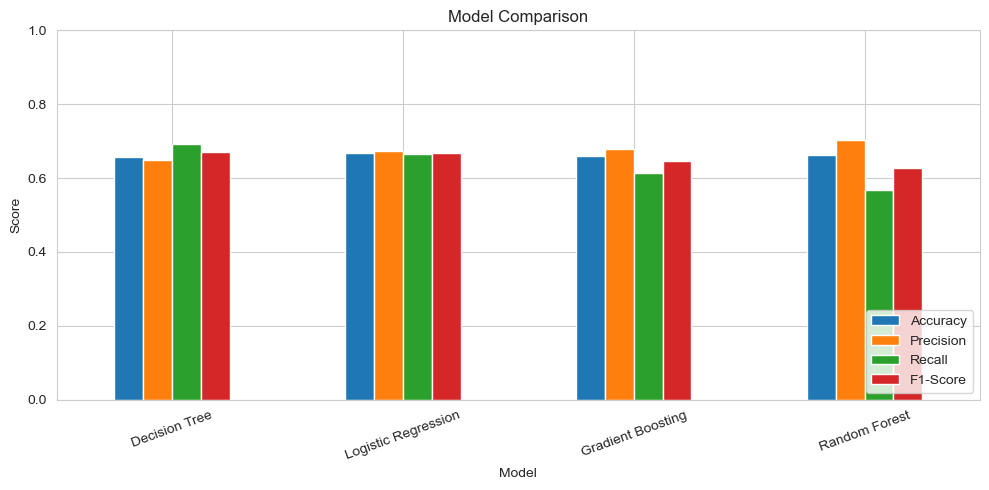

In [32]:
# Visual comparison of the four models
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', figsize=(10, 5)
)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [33]:
# Pick the best model based on F1-score (balances precision & recall -- important since
# missing a genuinely High Potential lead is as costly as chasing a Low Potential one)
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
best_preds = predictions[best_model_name]

print("Best model:", best_model_name)
print("\nClassification Report:\n")
print(classification_report(y_test, best_preds, target_names=label_encoder.classes_))


Best model: Decision Tree

Classification Report:

                precision    recall  f1-score   support

High Potential       0.67      0.62      0.64       738
 Low Potential       0.65      0.69      0.67       747

      accuracy                           0.66      1485
     macro avg       0.66      0.66      0.66      1485
  weighted avg       0.66      0.66      0.66      1485



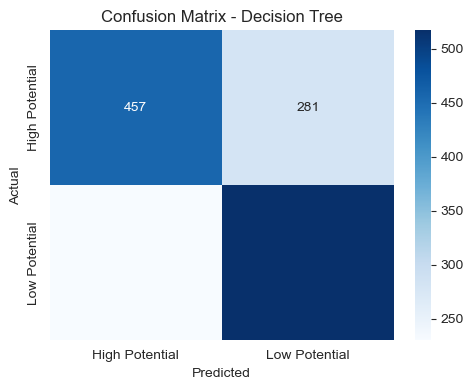

In [34]:
# Confusion matrix for the best model
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


<h2>Conclusions & Business Recommendations¶</h2>


<h3>Data insights:</h3>

The manually maintained Status field mixes 11 overlapping labels (and even a duplicate spelling of CONVERTED) — this confirms the client's own observation that manual categorization is inconsistent.
Lead volume is dominated by Call, Live Chat-Direct and Website, and by a handful of cities.
After deriving a clean 2-class target, the dataset is close to balanced (~50/50 High vs Low Potential), which is favourable for classification.


Problem: Missing values were identified in important categorical fields such as Source, Sales Agent, and Location.
Solution: Missing values were replaced with an Unknown category to retain the records without introducing incorrect information.


Problem: Product_ID was treated as a numerical field, even though it represents a product code rather than a measurable quantity.
Solution: Product_ID was converted and treated as a categorical feature.


Problem: Blank and invalid Product_ID values were present in the dataset.
Solution: Blank Product_ID values were identified and replaced with Unknown.


Problem: Invalid email values, including entries such as #VALUE!, were present in the EMAIL column.
Solution: Invalid email entries were handled appropriately, and the email domain was extracted as an additional feature where valid.


Problem: The Status field contained multiple and inconsistent categories, including duplicate/inconsistent labels.
Solution: Status values were standardized and converted into the required binary target classes: High Potential and Low Potential.


Problem: Machine learning algorithms cannot directly process categorical variables.
Solution: Categorical features were encoded using appropriate encoding techniques before model training.


Problem: Different machine learning algorithms produced different results.
Solution: Multiple classification models — Decision Tree, Logistic Regression, Gradient Boosting, and Random Forest — were trained and evaluated using Accuracy, Precision, Recall, and F1-score.

Problem: Accuracy alone does not fully represent the effectiveness of a lead-prediction model.
Solution: Recall and F1-score were also considered, since identifying as many High Potential leads as possible is important for sales prioritization.